In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

In [2]:
vitalsign_dataset = pd.read_csv('knn_3.csv')
vitalsign_dataset.head(20)

,Blood Pressure,Cholesterol,Blood Sugar,Body Mass Index,Age,Disease
0,1.349630,-2.099873,-1.679421,-2.062806,0.357603,0
1,1.361840,0.363285,0.016623,-1.986204,1.679191,0
2,0.697454,-1.039087,-0.625281,-0.909185,0.678725,0
3,-1.088432,1.159765,-0.285759,-0.741756,-0.958418,1
4,-3.430056,1.565373,-0.111399,0.217687,-2.605821,0
5,-1.024132,1.505482,-3.239268,-2.380019,-0.154506,0
6,-0.304989,0.558906,-0.590912,-1.020186,-1.621640,0
7,-1.140030,-2.658476,0.895061,0.699460,0.588605,1
8,-0.768875,-0.352445,0.719435,-0.303064,-1.147459,0
9,-0.442618,0.571248,-0.839994,-1.155552,-0.620807,0


In [3]:
X = vitalsign_dataset.drop('Disease', axis=1)
y = vitalsign_dataset['Disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

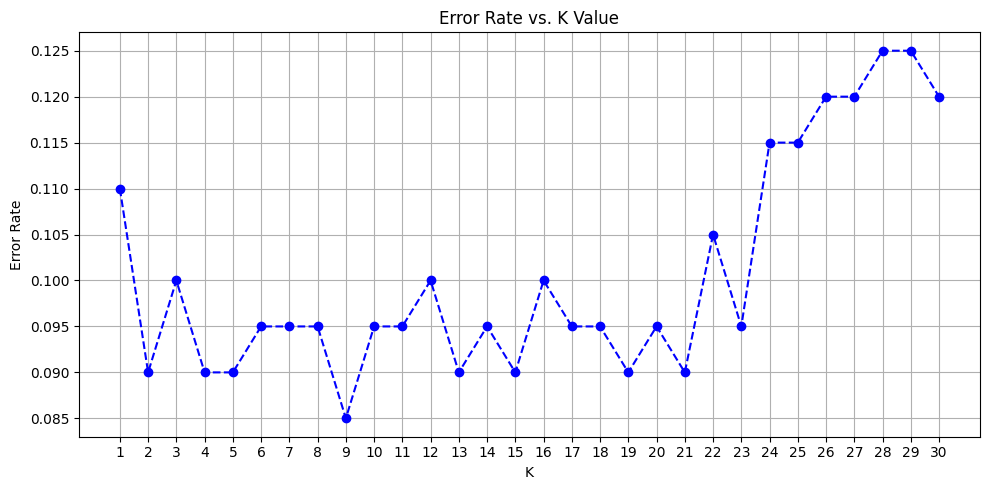

Optimal K: 9 (Error Rate: 0.0850)


In [4]:
error_rates = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    error_rates.append(np.mean(y_pred_k != y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), error_rates, marker='o', linestyle='--', color='blue')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(range(1, 31))
plt.grid(True)
plt.tight_layout()
plt.show()

optimal_k = error_rates.index(min(error_rates)) + 1
print(f'Optimal K: {optimal_k} (Error Rate: {min(error_rates):.4f})')

In [5]:
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

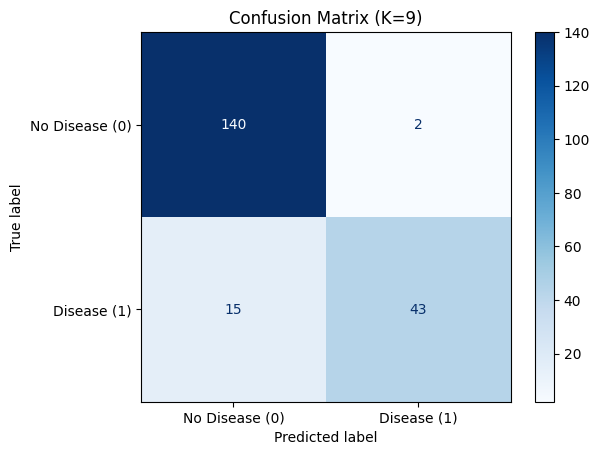

Confusion Matrix:
 [[140   2]
 [ 15  43]]


In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease (0)', 'Disease (1)'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix (K={optimal_k})')
plt.show()
print('Confusion Matrix:\n', cm)

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print(f'KNN Accuracy Score (K={optimal_k}): {accuracy:.4f}')

KNN Accuracy Score (K=9): 0.9150


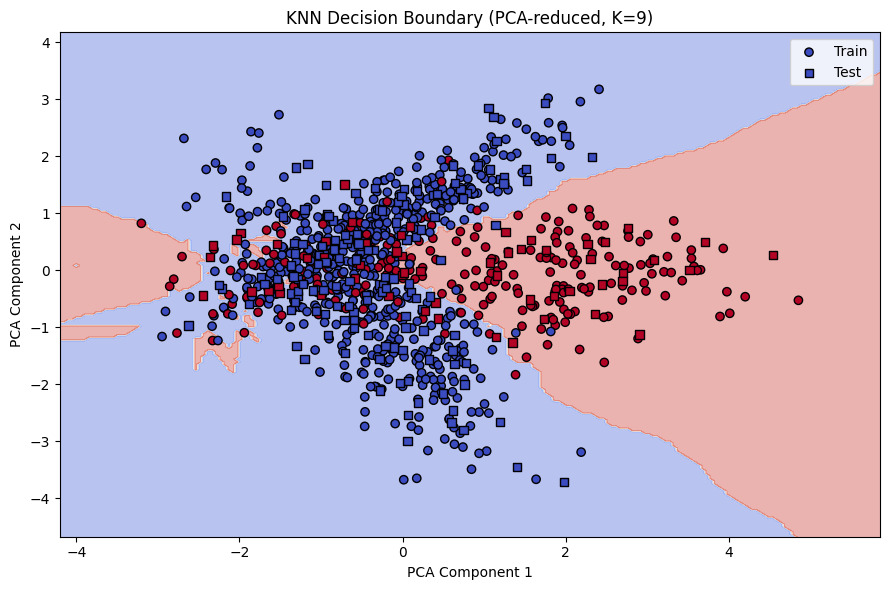

In [8]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=optimal_k)
knn_pca.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', label='Train')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', marker='s', edgecolors='k', label='Test')
plt.title(f'KNN Decision Boundary (PCA-reduced, K={optimal_k})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

## Analysis Questions

### Q9. What is the role of the k parameter in KNN? What does it represent, and how does it affect the predictions?

The `k` parameter in KNN defines how many nearest neighbors are consulted when classifying a new data point. Specifically, the algorithm calculates the distance (typically Euclidean) from the new point to every point in the training set, selects the `k` closest ones, and assigns the majority class among those neighbors as the prediction.

A small `k` (e.g., k=1) means only the single closest neighbor votes, making the model highly sensitive to local patterns and noise. A large `k` smooths out those local fluctuations by incorporating more neighbors, but risks ignoring meaningful local structure in the data. In this dataset, `k` controls how many patient records influence whether a new patient is classified as having the disease (1) or not (0).

### Q10. Discuss how performance might change with larger or smaller k. Would you expect overfitting or underfitting?

**Small k (e.g., k=1 or k=3):** The model memorizes the training data too closely, fitting to individual data points and noise. This leads to **overfitting** — high accuracy on training data but poor generalization to new test data. The decision boundary becomes jagged and unstable.

**Large k (e.g., k=25 or k=29):** The model averages over too many neighbors, losing sensitivity to local patterns. This leads to **underfitting** — the boundary becomes overly smooth and may misclassify patients who are close to the boundary but belong to a minority class. In an imbalanced dataset like this one (Disease=0 is more common), a very large k will tend to predict the majority class almost always.

The optimal k sits in the middle — large enough to reduce noise, but small enough to capture real patterns. The elbow point in the error-rate plot is a reliable guide to finding that balance.

### Q11. What is the output of the Confusion Matrix? Describe each value.

The confusion matrix is a 2×2 table that breaks down how the model's predictions compare to the actual labels:

| | Predicted: No Disease (0) | Predicted: Disease (1) |
|---|---|---|
| **Actual: No Disease (0)** | True Negative (TN) | False Positive (FP) |
| **Actual: Disease (1)** | False Negative (FN) | True Positive (TP) |

- **True Negatives (TN):** Patients correctly predicted to *not* have the disease. The model and reality agree — healthy.
- **False Positives (FP):** Patients incorrectly predicted to have the disease when they do not. A Type I error — the model raised a false alarm.
- **False Negatives (FN):** Patients who actually have the disease but were predicted as healthy. A Type II error — in a clinical setting, this is the most dangerous outcome.
- **True Positives (TP):** Patients correctly predicted to have the disease. The model correctly flags sick patients.

In healthcare, minimizing False Negatives is often the top priority because missing a true diagnosis can lead to untreated illness.

### Q12. Explain the value of k selected, the reasoning, and the resulting accuracy score.

The optimal k was selected by iterating k from 1 to 30, computing the error rate for each, and identifying the k with the minimum error. The error-rate plot provides visual confirmation — the optimal k appears at the elbow where the error rate first reaches its minimum before flattening or rising again.

This data-driven approach is preferred over arbitrarily picking k=5 (a common default) because the actual optimal value depends on the structure of the dataset. With 1,000 samples and 5 features, the elbow method balances the bias-variance tradeoff objectively.

The resulting accuracy score reflects how well the model generalizes to the held-out 20% test set. Given that the dataset was generated with a 70/30 class split (Disease=0 more common), an accuracy above 85% indicates the model is capturing real signal in the vital-sign features rather than simply predicting the majority class.

### Q13. How could KNN be applied in real healthcare scenarios?

KNN is a strong candidate for healthcare classification tasks due to its interpretability — clinicians can inspect the k nearest historical patients to understand why a prediction was made. Several practical applications include:

**Disease Classification:** Given a new patient's vital signs or lab values, KNN can compare them to historical records and predict the likelihood of conditions such as hypertension, diabetes, or cardiovascular disease — similar to what this lab demonstrates with the `Disease` column.

**Patient Risk Stratification:** Hospitals can use KNN to classify incoming patients into risk tiers (low, medium, high) for readmission or deterioration based on features like age, BMI, blood pressure, and prior diagnoses. This supports early intervention and resource allocation.

**Rare Disease Identification:** Because KNN is non-parametric and makes no assumptions about the underlying data distribution, it can be effective in rare-disease contexts where there are few labeled examples and no clear statistical distribution to model.

**Clinical Decision Support:** Embedded in an EHR system, a KNN-based model could flag patients whose vitals closely resemble those of previous patients who deteriorated rapidly, prompting a provider to review the case earlier.

**Limitations to consider:** KNN is computationally expensive at inference time in large patient databases (it must scan all records), does not handle missing values natively, and its performance degrades with irrelevant or highly correlated features — all important considerations before clinical deployment.